## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 9: Boosting — Gradient Boosting, XGBoost/LightGBM y Riesgo de Modelo**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 30 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución (uso de información futura en la construcción de features, en el ajuste del pseudo-residuo, o en la partición train/val/test), esa parte se evalúa con nota 1.0
* Deben crear una rama nueva en su repositorio `feat/hw07` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, mean_squared_error, accuracy_score
)
from scipy.stats import spearmanr
import xgboost as xgb
import lightgbm as lgb
import yfinance as yf
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

---
## Datos Base

Reutilizamos el problema de **eventos de cola** de la sesión 9 (retorno del día siguiente en el percentil 5 más bajo), con los mismos 7 features. A diferencia de la sesión, aquí agregamos un split de **validación** explícito (70/15/15) porque varias partes de esta tarea (2.1, 2.2) requieren *early stopping*, que necesita un set de validación separado del set de test.

In [2]:
TICKER = "AAPL"

raw = yf.download(TICKER, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

close = raw["Close"]
ret = close.pct_change()

feat = pd.DataFrame(index=raw.index)
feat["ret_lag1"] = ret.shift(1)
feat["ret_lag2"] = ret.shift(2)
feat["ret_lag5"] = ret.shift(1).rolling(5).sum()
feat["vol_20"]   = ret.shift(1).rolling(20).std() * np.sqrt(252)
feat["mom_10"]   = close.shift(1) / close.shift(11) - 1
delta = close.diff()
gain = delta.clip(lower=0).shift(1).rolling(14).mean()
loss = (-delta.clip(upper=0)).shift(1).rolling(14).mean()
feat["rsi_14"]   = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
feat["vol_chg"]  = raw["Volume"].pct_change().shift(1)
feat["target"]   = (ret.shift(-1) <= ret.quantile(0.05)).astype(int)   # 1 = evento de cola
feat = feat.dropna()

FEATURES = ["ret_lag1", "ret_lag2", "ret_lag5", "vol_20", "mom_10", "rsi_14", "vol_chg"]

X = feat[FEATURES].values
y = feat["target"].values

split_tr = int(len(feat) * 0.70)
split_va = int(len(feat) * 0.85)
X_train, X_val, X_test = X[:split_tr], X[split_tr:split_va], X[split_va:]
y_train, y_val, y_test = y[:split_tr], y[split_tr:split_va], y[split_va:]

print(f"{TICKER}: {feat.shape[0]} obs | {len(FEATURES)} features")
print(f"Train: {len(y_train)} obs | Val: {len(y_val)} obs | Test: {len(y_test)} obs")
print(f"Tasa de eventos de cola — train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")

AAPL: 2243 obs | 7 features
Train: 1570 obs | Val: 336 obs | Test: 337 obs
Tasa de eventos de cola — train: 4.97% | val: 5.65% | test: 4.45%


---
## Parte 1 — Gradient Boosting desde Cero: Pseudo-Residuos por Función de Pérdida *(25 pts)*

### Contexto

En la sesión 9 vimos el algoritmo de Friedman (2001): dado $F_0(x)$ (una constante), en cada ronda $m$ se calcula el **pseudo-residuo** (el gradiente negativo de la pérdida respecto a las predicciones actuales),

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

se ajusta un árbol débil $h_m$ a esos pseudo-residuos, y se actualiza $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$. En clase implementamos esto **solo para pérdida cuadrática** (regresión), donde el pseudo-residuo es simplemente el residuo ordinario $y_i - F_{m-1}(x_i)$. Esta parte te pide completar el algoritmo general: implementarlo para MSE (1.1) y luego derivar y programar el caso de **log-loss** para clasificación binaria (1.2), que es exactamente lo que XGBoost/LightGBM hacen internamente (con una aproximación de segundo orden que aquí no exigimos replicar).

### 1.1 — Gradient Boosting para Regresión (MSE) *(13 pts)*

**Requisitos:**
1. Implementa `gradient_boosting_fit` y `gradient_boosting_predict` completando los TODOs de la celda siguiente
2. Verifica tu implementación sobre la misma función seno con ruido de la sesión 9 (la celda de verificación ya genera esos datos): compara el MSE final de tu modelo manual contra `GradientBoostingRegressor` de sklearn con los mismos `n_estimators`, `learning_rate` y `max_depth`
3. Grafica ambas curvas de ajuste (manual vs sklearn) superpuestas sobre los datos, y el MSE por ronda de tu implementación manual
4. Tu implementación debe alcanzar un MSE final dentro de un 15% del de sklearn (ambos algoritmos deberían converger a soluciones muy similares, no idénticas — sklearn usa optimizaciones internas adicionales)

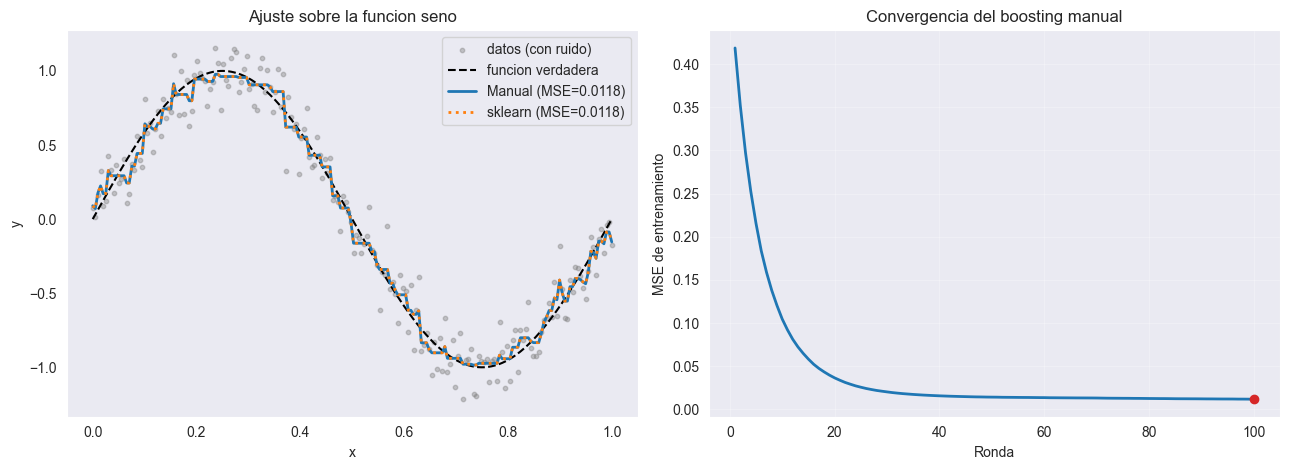

MSE manual:        0.011771
MSE sklearn:       0.011771
Diferencia relativa: 0.00%


In [3]:
def gradient_boosting_fit(X, y, n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42):
    '''
    Ajusta un modelo de Gradient Boosting para regresion (perdida MSE) desde cero.

    Sigue el algoritmo de Friedman (2001): en cada ronda, ajusta un arbol a los
    pseudo-residuos (para MSE, el residuo ordinario y - F_(m-1)(x)) y actualiza
    F_m(x) = F_(m-1)(x) + learning_rate * arbol_m(x).

    Parameters
    ----------
    X, y          : arrays de entrenamiento
    n_estimators  : int   — numero de rondas de boosting (M)
    learning_rate : float — shrinkage (nu)
    max_depth     : profundidad de cada arbol debil
    random_state  : semilla maestra (debe generar semillas reproducibles por arbol)

    Returns
    -------
    F0    : float — prediccion constante inicial (media de y)
    trees : list de DecisionTreeRegressor, uno por ronda, ajustados al pseudo-residuo de esa ronda
    '''
    X = np.asarray(X)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if X.shape[0] != y.size:
        raise ValueError("X e y deben contener el mismo numero de observaciones")
    if n_estimators < 1 or learning_rate <= 0 or max_depth < 1:
        raise ValueError("n_estimators, learning_rate y max_depth deben ser positivos")

    F0 = float(y.mean())
    pred_train = np.full(y.shape, F0, dtype=float)
    trees = []
    rng = np.random.default_rng(random_state)

    for _ in range(n_estimators):
        pseudo_residual = y - pred_train
        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            criterion="friedman_mse",
            random_state=int(rng.integers(0, np.iinfo(np.int32).max)),
        )
        tree.fit(X, pseudo_residual)
        pred_train += learning_rate * tree.predict(X)
        trees.append(tree)

    return F0, trees


def gradient_boosting_predict(F0, trees, X, learning_rate=0.1):
    '''
    Parameters
    ----------
    F0     : constante inicial devuelta por gradient_boosting_fit
    trees  : lista de arboles devuelta por gradient_boosting_fit
    X      : datos sobre los que predecir
    learning_rate : debe ser el mismo usado en el fit

    Returns
    -------
    pred : array — F0 + suma(learning_rate * arbol.predict(X) para cada arbol en trees)
    '''
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    pred = np.full(X.shape[0], float(F0), dtype=float)
    for tree in trees:
        pred += learning_rate * tree.predict(X)
    return pred


# === Verificacion ===
np.random.seed(42)
x_gb = np.linspace(0, 1, 200).reshape(-1, 1)
y_true_gb = np.sin(2 * np.pi * x_gb).ravel()
y_gb = y_true_gb + np.random.normal(0, 0.15, len(x_gb))

N_EST, LR, DEPTH = 100, 0.1, 2
F0_manual, trees_manual = gradient_boosting_fit(
    x_gb, y_gb, n_estimators=N_EST, learning_rate=LR,
    max_depth=DEPTH, random_state=42,
)
pred_manual = gradient_boosting_predict(F0_manual, trees_manual, x_gb, learning_rate=LR)

gbr_ref = GradientBoostingRegressor(
    n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH, random_state=42,
).fit(x_gb, y_gb)
pred_ref = gbr_ref.predict(x_gb)

mse_manual = mean_squared_error(y_gb, pred_manual)
mse_ref = mean_squared_error(y_gb, pred_ref)
mse_relative_diff = abs(mse_manual - mse_ref) / mse_ref

staged_pred = np.full_like(y_gb, F0_manual, dtype=float)
mse_by_round = []
for tree in trees_manual:
    staged_pred += LR * tree.predict(x_gb)
    mse_by_round.append(mean_squared_error(y_gb, staged_pred))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(x_gb.ravel(), y_gb, s=10, color="gray", alpha=0.4, label="datos (con ruido)")
ax[0].plot(x_gb.ravel(), y_true_gb, "k--", lw=1.5, label="funcion verdadera")
ax[0].plot(x_gb.ravel(), pred_manual, lw=2, label=f"Manual (MSE={mse_manual:.4f})")
ax[0].plot(x_gb.ravel(), pred_ref, lw=2, ls=":", label=f"sklearn (MSE={mse_ref:.4f})")
ax[0].set(title="Ajuste sobre la funcion seno", xlabel="x", ylabel="y")
ax[0].legend()

ax[1].plot(range(1, N_EST + 1), mse_by_round, color="tab:blue", lw=2)
ax[1].scatter(N_EST, mse_by_round[-1], color="tab:red", zorder=3)
ax[1].set(title="Convergencia del boosting manual", xlabel="Ronda", ylabel="MSE de entrenamiento")
ax[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"MSE manual:        {mse_manual:.6f}")
print(f"MSE sklearn:       {mse_ref:.6f}")
print(f"Diferencia relativa: {mse_relative_diff:.2%}")
assert mse_relative_diff <= 0.15, "El MSE manual excede la tolerancia de 15%"

### 1.2 — Extensión a Clasificación Binaria: Pseudo-Residuo de Log-Loss *(12 pts)*

Para clasificación binaria con log-loss, $F(x)$ representa el **log-odds** (margen, antes de la sigmoide) y la pérdida es $L(y, F) = -[y\log p + (1-y)\log(1-p)]$ con $p = \sigma(F) = 1/(1+e^{-F})$. Deberás derivar (a mano, en la celda de texto siguiente) el pseudo-residuo $r_{im} = -\partial L/\partial F$ para esta pérdida, y usarlo para completar la implementación.

**Requisitos:**
1. En la celda markdown de abajo, muestra el desarrollo de $-\partial L(y,F)/\partial F$ y confirma que se reduce a $y - \sigma(F)$
2. Implementa `gradient_boosting_logloss_fit` y `gradient_boosting_logloss_predict_proba`, reutilizando la misma estructura de 1.1 pero con: (a) $F_0 = \text{logit}(\bar{y})$ (log-odds de la tasa base) en vez de la media, y (b) el pseudo-residuo derivado arriba en vez del residuo ordinario
3. Verifica tu implementación sobre el dataset sintético que genera la celda de verificación (`make_classification`, moderadamente balanceado — a propósito, para no mezclar este chequeo con el problema de desbalance severo de la Parte 3), comparando el AUC de test contra `xgb.XGBClassifier` con los mismos `n_estimators`/`learning_rate`/`max_depth`
4. Tu AUC manual debe quedar dentro de 0.05 del AUC de XGBoost (tu versión es una aproximación de primer orden sin regularización — XGBoost usa una aproximación de segundo orden con $\lambda$, así que una diferencia pequeña es esperable, no un error)

**Derivación:**

$$L(y, F) = -\Big[y\log \sigma(F) + (1-y)\log(1-\sigma(F))\Big], \qquad \sigma(F) = \frac{1}{1+e^{-F}}$$

Definamos $p=\sigma(F)$. Aplicando la regla de la cadena y usando $p'=p(1-p)$:

$$\frac{\partial L}{\partial F}=-\left[\frac{y}{p}p' + \frac{1-y}{1-p}(-p')\right]$$

$$=-\left[y(1-p)-(1-y)p\right]=-\left[y-p\right]=p-y.$$

Por lo tanto, el gradiente negativo o pseudo-residuo de la observación $i$ en la ronda $m$ es

$$r_{im}=-\left.\frac{\partial L}{\partial F}\right|_{F=F_{m-1}(x_i)}=y_i-\sigma\!\left(F_{m-1}(x_i)\right).$$

Es decir, se ajusta cada árbol a la diferencia entre la etiqueta observada y la probabilidad estimada en la ronda anterior.

In [4]:
def gradient_boosting_logloss_fit(X, y, n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42):
    '''
    Ajusta un modelo de Gradient Boosting para clasificacion binaria (log-loss) desde cero.

    F representa el log-odds (margen). El pseudo-residuo de cada ronda es el que
    derivaste arriba: y - sigmoid(F_(m-1)(x)).

    Parameters
    ----------
    X, y          : arrays de entrenamiento (y en {0,1})
    n_estimators  : int
    learning_rate : float
    max_depth     : profundidad de cada arbol debil
    random_state  : semilla maestra

    Returns
    -------
    F0    : float — logit de la tasa base de y (log-odds de y.mean())
    trees : list de DecisionTreeRegressor ajustados al pseudo-residuo logistico de cada ronda
    '''
    X = np.asarray(X)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if X.shape[0] != y.size:
        raise ValueError("X e y deben contener el mismo numero de observaciones")
    if not np.isin(y, [0.0, 1.0]).all():
        raise ValueError("y debe contener exclusivamente las clases 0 y 1")
    if n_estimators < 1 or learning_rate <= 0 or max_depth < 1:
        raise ValueError("n_estimators, learning_rate y max_depth deben ser positivos")

    base_rate = np.clip(y.mean(), 1e-12, 1 - 1e-12)
    F0 = float(np.log(base_rate / (1 - base_rate)))
    margin_train = np.full(y.shape, F0, dtype=float)
    trees = []
    rng = np.random.default_rng(random_state)

    for _ in range(n_estimators):
        proba_train = 1.0 / (1.0 + np.exp(-np.clip(margin_train, -709, 709)))
        pseudo_residual = y - proba_train
        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            criterion="friedman_mse",
            random_state=int(rng.integers(0, np.iinfo(np.int32).max)),
        )
        tree.fit(X, pseudo_residual)
        margin_train += learning_rate * tree.predict(X)
        trees.append(tree)

    return F0, trees


def gradient_boosting_logloss_predict_proba(F0, trees, X, learning_rate=0.1):
    '''
    Returns
    -------
    proba : array — sigmoid(F0 + suma(learning_rate * arbol.predict(X)))
    '''
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    margin = np.full(X.shape[0], float(F0), dtype=float)
    for tree in trees:
        margin += learning_rate * tree.predict(X)
    return 1.0 / (1.0 + np.exp(-np.clip(margin, -709, 709)))


# === Verificacion ===
X_synth, y_synth = make_classification(
    n_samples=2000, n_features=8, n_informative=5, weights=[0.7, 0.3],
    class_sep=1.0, random_state=42,
)
X_synth_tr, X_synth_te, y_synth_tr, y_synth_te = train_test_split(
    X_synth, y_synth, test_size=0.30, stratify=y_synth, random_state=42,
)

N_EST2, LR2, DEPTH2 = 100, 0.1, 2
F0_cls, trees_cls = gradient_boosting_logloss_fit(
    X_synth_tr, y_synth_tr, n_estimators=N_EST2, learning_rate=LR2,
    max_depth=DEPTH2, random_state=42,
)
proba_manual_cls = gradient_boosting_logloss_predict_proba(
    F0_cls, trees_cls, X_synth_te, learning_rate=LR2,
)
auc_manual_cls = roc_auc_score(y_synth_te, proba_manual_cls)

xgb_ref_cls = xgb.XGBClassifier(
    n_estimators=N_EST2, learning_rate=LR2, max_depth=DEPTH2,
    reg_lambda=0.0, eval_metric="auc", random_state=42, n_jobs=1,
).fit(X_synth_tr, y_synth_tr)
auc_ref_cls = roc_auc_score(y_synth_te, xgb_ref_cls.predict_proba(X_synth_te)[:, 1])
auc_absolute_diff = abs(auc_manual_cls - auc_ref_cls)

print(f"AUC manual:          {auc_manual_cls:.6f}")
print(f"AUC XGBoost:         {auc_ref_cls:.6f}")
print(f"Diferencia absoluta: {auc_absolute_diff:.6f}")
assert auc_absolute_diff <= 0.05, "El AUC manual excede la tolerancia absoluta de 0.05"

AUC manual:          0.922098
AUC XGBoost:         0.961748
Diferencia absoluta: 0.039650


### Preguntas de Interpretación — Parte 1

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué diferencia concreta existe entre el pseudo-residuo de MSE (1.1) y el de log-loss (1.2)? ¿Por qué ambos se llaman "residuo" a pesar de tener fórmulas distintas — qué propiedad comparten?

> En MSE, el pseudo-residuo es $y-F(x)$ porque $F(x)$ es directamente una predicción continua; en log-loss es $y-\sigma(F(x))$, pues $F(x)$ es un log-odds y debe transformarse a probabilidad. Ambos reciben el nombre de residuo porque son el gradiente negativo de su respectiva pérdida respecto de la predicción actual: indican la dirección local de máximo descenso que el siguiente árbol debe aproximar.

**b)** Reporta la diferencia de MSE (1.1) y de AUC (1.2) entre tu implementación manual y la de referencia. ¿A qué atribuyes la diferencia remanente, sabiendo que tu versión no usa aproximación de segundo orden ni regularización $\lambda$?

> En 1.1 se obtuvo un MSE manual de $0.011771$ y un MSE de sklearn de $0.011771$, con una diferencia relativa de $0.00\%$ a la precisión reportada. En 1.2, el AUC manual fue $0.922098$ y el de XGBoost $0.961748$, una diferencia absoluta de $0.039650$ que cumple la tolerancia de $0.05$; la brecha se explica principalmente porque XGBoost usa gradiente y Hessiano para evaluar splits y calcular pesos de hoja, mientras la versión manual ajusta árboles por MSE únicamente al gradiente de primer orden. En esta comparación se fijó `reg_lambda=0`, por lo que la penalización $\lambda$ no explica la brecha, aunque sí permanecen otros mecanismos internos de XGBoost como `min_child_weight` y su criterio de ganancia.

**c)** Si quisieras extender tu implementación de 1.2 a un problema con la pérdida de Huber (robusta a outliers) en vez de log-loss, ¿qué tendrías que cambiar en el código? Sé específico sobre qué función(es) modificarías.

> Para usar pérdida de Huber cambiaría la función de ajuste: reemplazaría el logit inicial por una constante robusta —por ejemplo, la mediana— y el pseudo-residuo logístico por $r=y-F$ cuando $|y-F|\leq\delta$, y por $r=\delta\,\operatorname{sign}(y-F)$ fuera de ese rango. También modificaría la función de predicción para devolver directamente la suma aditiva, sin sigmoide, eliminaría la validación binaria de $y$ y evaluaría con una métrica de regresión o con la propia pérdida de Huber en lugar de AUC.

---
## Parte 2 — Hiperparámetros, Overfitting y Validación Walk-Forward *(25 pts)*

### Contexto

La sesión 9 mostró que, a diferencia de Random Forest, boosting **sí puede sobreajustar** con más rondas — el AUC de validación forma una "U invertida" en función de `n_estimators`, lo que hace obligatorio el *early stopping*. También vimos que LightGBM crece los árboles *leaf-wise* (más agresivo, converge más rápido pero sobreajusta más fácil) mientras XGBoost crece *level-wise* por defecto. Esta parte te pide reproducir ambos diagnósticos con tus propios datos (`X_train, X_val, X_test` de la sección "Datos Base") y comparar XGBoost vs LightGBM directamente.

### 2.1 — Overfitting sin Early Stopping: XGBoost vs LightGBM *(10 pts)*

**Requisitos:**
1. Entrena un `xgb.XGBClassifier` y un `lgb.LGBMClassifier`, cada uno con `n_estimators=500` y **sin** `early_stopping_rounds`, sobre `X_train, y_train`
2. Para cada modelo, calcula el AUC de train y de validación (`X_val, y_val`) usando `iteration_range` (XGBoost) o el parámetro equivalente de predicción parcial de LightGBM, en incrementos de al menos 20 rondas
3. Grafica ambas curvas (train/val AUC vs ronda) en dos paneles, uno por modelo, marcando la ronda óptima de validación en cada uno
4. Reporta la ronda óptima de cada modelo y compara

In [5]:
# TODO: entrenar XGBoost y LightGBM con n_estimators=500 sin early stopping
# xgb_of = xgb.XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=4, random_state=42)
# xgb_of.fit(X_train, y_train)
# lgb_of = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.1, num_leaves=15, random_state=42, verbosity=-1)
# lgb_of.fit(X_train, y_train)

# TODO: calcular AUC train/val por ronda para ambos modelos (incrementos de al menos 20 rondas)
# rounds = list(range(1, 501, 20))
# ...

# TODO: grafico de 2 paneles (XGBoost, LightGBM) con train/val AUC vs ronda + linea vertical en la ronda optima
# ...

# TODO: imprimir la ronda optima de cada modelo

### 2.2 — Grid Search Walk-Forward: Selección de Hiperparámetros vs Early Stopping *(15 pts)*

**Requisitos:**
1. Construye un `Pipeline` (`SimpleImputer` + `StandardScaler` + `clf`) para XGBoost y otro para LightGBM
2. Define un grid de hiperparámetros para cada uno (mínimo 3 valores por hiperparámetro, mínimo 2 hiperparámetros): para XGBoost usa `max_depth` y `learning_rate`; para LightGBM usa `num_leaves` y `learning_rate`
3. Ejecuta `GridSearchCV` con `TimeSeriesSplit(n_splits=5)` sobre `X_train_full = vstack([X_train, X_val])` (concatenando train+val, igual que en la sesión 9), y reporta el mejor score de CV y los mejores hiperparámetros de cada modelo
4. Por separado, entrena cada modelo con *early stopping* (usando `X_val, y_val` como set de validación) y compara el AUC de **test** de ambos enfoques (grid search + refit vs early stopping) en una tabla
5. En las preguntas de interpretación, discute cuál enfoque preferirías para un modelo que se reentrena diariamente vs uno que se reentrena trimestralmente (la sesión 9 plantea esta distinción explícitamente)

In [6]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# TODO: Pipeline + GridSearchCV con TimeSeriesSplit para XGBoost
# pipe_xgb = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler()),
#     ("clf", xgb.XGBClassifier(eval_metric="auc", random_state=42)),
# ])
# param_grid_xgb = {
#     "clf__max_depth": [2, 3, 4],
#     "clf__learning_rate": [0.03, 0.1, 0.3],
# }
# tscv = TimeSeriesSplit(n_splits=5)
# grid_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, scoring="roc_auc", cv=tscv, n_jobs=-1)
# grid_xgb.fit(X_train_full, y_train_full)

# TODO: Pipeline + GridSearchCV con TimeSeriesSplit para LightGBM (mismo patron, otro grid)
# ...

# TODO: entrenar cada modelo por separado con early stopping sobre X_val, y_val
# ...

# TODO: tabla comparativa AUC de test — grid search+refit vs early stopping, para XGBoost y LightGBM
# ...

### Preguntas de Interpretación — Parte 2

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿En qué ronda óptima se detiene cada modelo en 2.1? Si LightGBM se detiene antes que XGBoost, conecta esto con la tabla de la sesión 9 sobre crecimiento leaf-wise vs level-wise. Si no es así, propón una explicación alternativa basada en tus hiperparámetros elegidos.

> *Completa aquí*

**b)** Compara el AUC de test de "grid search + refit" vs "early stopping" para ambos modelos (2.2). ¿Cuál enfoque ganó? ¿La diferencia justifica el costo computacional adicional del grid search?

> *Completa aquí*

**c)** Un banco reentrena su modelo de riesgo de crédito diariamente con datos nuevos. Otro banco solo revisa su modelo trimestralmente. ¿Qué enfoque (early stopping vs grid search walk-forward) recomendarías a cada uno, y por qué?

> *Completa aquí*

---
## Parte 3 — Feature Importance y Sensibilidad a Ruido: Boosting vs Bagging *(25 pts)*

### Contexto

XGBoost expone tres métricas de importancia (`Weight`, `Gain`, `Cover`) que pueden rankear features de forma distinta — la sesión 9 mostró que esto revela información que una sola métrica esconde. También vimos que, en teoría, boosting es más sensible a ruido de etiquetas que bagging porque ajusta secuencialmente al residuo. Esta parte te pide cuantificar ambos fenómenos con más rigor del que se hizo en clase.

### 3.1 — Weight vs Gain vs Cover: Cuantificando el Desacuerdo *(13 pts)*

**Requisitos:**
1. Entrena un `xgb.XGBClassifier` sobre `X_train, y_train` (usa hiperparámetros razonables, con `early_stopping_rounds` sobre `X_val, y_val`)
2. Extrae las tres métricas de importancia (`weight`, `gain`, `cover`) y constrúyelas en un DataFrame indexado por `FEATURES`
3. Calcula la correlación de Spearman **entre cada par** de las tres métricas (Weight-Gain, Weight-Cover, Gain-Cover) — 3 números
4. Identifica el feature con **mayor discrepancia** entre su ranking de `Weight` y su ranking de `Gain` (mayor diferencia absoluta de rangos), y en las preguntas de interpretación explica el mecanismo (¿se usa poco pero aporta mucho, o se usa mucho pero aporta poco?)

In [7]:
# TODO: entrenar XGBoost con early stopping (reutiliza X_train/X_val/y_train/y_val)
# xgb_imp = xgb.XGBClassifier(
#     n_estimators=1000, learning_rate=0.03, max_depth=3,
#     eval_metric="auc", early_stopping_rounds=50, random_state=42
# )
# xgb_imp.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# TODO: extraer weight/gain/cover en un DataFrame indexado por FEATURES
# importance_types = ["weight", "gain", "cover"]
# imp_df = ...

# TODO: correlacion de Spearman entre cada par de columnas (3 pares)
# ...

# TODO: identificar el feature con mayor |rank_weight - rank_gain|
# ...

### 3.2 — Sensibilidad a Ruido de Etiquetas: RF vs XGBoost vs LightGBM, y una Mitigación *(12 pts)*

**Requisitos:**
1. Extiende el experimento de la sesión 9 (contaminación de etiquetas de train) a **tres** modelos: `RandomForestClassifier`, `XGBoost`, `LightGBM`
2. Usa `noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]` y al menos 10 semillas por nivel (más que las 8 de la sesión, para una estimación más estable de la desviación estándar)
3. Para cada modelo y nivel de ruido, calcula el **coeficiente de variación** $CV = \text{std}/\text{mean}$ del AUC de test entre semillas — esta es tu métrica cuantitativa de inestabilidad (más alta = más sensible al ruido específico de las etiquetas volteadas)
4. Grafica el CV vs nivel de ruido para los tres modelos en un mismo gráfico
5. **Mitigación:** al nivel de ruido más alto (0.30), reentrena XGBoost y LightGBM con `min_child_weight`/`min_data_in_leaf` y `reg_lambda` aumentados (elige valores y justifica), y verifica si el CV baja frente a la versión sin mitigar, reportando también cuánto AUC promedio se sacrifica

In [8]:
# TODO: experimento de ruido de etiquetas para RF, XGBoost y LightGBM
# noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
# n_repeats = 10
# noise_results = []
# for noise_frac in noise_levels:
#     aucs = {"RF": [], "XGBoost": [], "LightGBM": []}
#     for rep in range(n_repeats):
#         ...  # voltear etiquetas, entrenar los 3 modelos, guardar AUC de test
#     noise_results.append({...})  # mean y std de AUC por modelo, a este nivel de ruido

# TODO: calcular CV = std/mean por modelo y nivel de ruido, graficar vs noise_frac

# TODO: mitigacion a noise_frac=0.30 — reentrenar XGBoost/LightGBM con min_child_weight/min_data_in_leaf
# y reg_lambda mas altos, comparar CV y AUC promedio vs la version sin mitigar

### Preguntas de Interpretación — Parte 3

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué feature mostró la mayor discrepancia Weight vs Gain en 3.1? Explica el mecanismo: ¿se usa con poca frecuencia pero cada split aporta mucho, o se usa con frecuencia pero cada split aporta poco?

> *Completa aquí*

**b)** Compara las curvas de CV vs ruido de los tres modelos (3.2). ¿Confirma tu experimento la hipótesis teórica de que boosting es más inestable que bagging? Si algún resultado contradice la teoría, propón una explicación.

> *Completa aquí*

**c)** ¿Tu mitigación (min_child_weight/min_data_in_leaf + reg_lambda más altos) logró bajar el CV a noise_frac=0.30? ¿Cuánto AUC promedio costó esa estabilidad? ¿Consideras que el trade-off vale la pena para un modelo de producción con etiquetas potencialmente ruidosas (ej. default reportado con rezago)?

> *Completa aquí*

---
## Parte 4 — Aplicación Financiera: Extrapolación y Restricciones Monótonas *(25 pts)*

### Contexto

Boosting hereda la limitación de extrapolación de los árboles de decisión (cada hoja predice un valor constante) — no importa cuántas rondas se agreguen, la predicción nunca supera el rango de $y$ visto en entrenamiento. También vimos que XGBoost/LightGBM permiten imponer restricciones de monotonía (`monotone_constraints`) para cumplimiento regulatorio. Esta parte te pide poner ambas ideas a prueba en escenarios nuevos, no simplemente repetir la demostración de la sesión 9.

### 4.1 — Límite de Extrapolación en una Ventana de Crisis Distinta a COVID *(13 pts)*

**Requisitos:**
1. Elige una ventana de estrés **distinta** a la crisis COVID-19 vista en clase — por ejemplo, el shock de tasas de 2022 (`2022-01-01` a `2022-10-31`) o el selloff de agosto 2024 (`2024-07-01` a `2024-09-30`)
2. Construye `rv_20` (volatilidad realizada anualizada, ventana 20 días) y features rezagadas `rv_lag1`, `rv_lag5`, `rv_lag22`, igual que en la sesión 9
3. Entrena con datos **estrictamente anteriores** al inicio de tu ventana de crisis: `XGBoost`, `LightGBM`, `RandomForestRegressor` y `Ridge`
4. Reporta y grafica: `max(y_train)` vs `max(y_test)` vs el máximo predicho por cada uno de los 4 modelos, más el RMSE de cada modelo en la ventana de crisis
5. Confirma explícitamente si los tres modelos basados en árboles quedan acotados por el máximo de train, y si Ridge se comporta distinto

In [9]:
# TODO: elegir ventana de crisis (distinta a COVID) y construir rv_20 + lags
# CRISIS_START = "2022-01-01"   # ejemplo — puedes cambiar la ventana
# CRISIS_END   = "2022-10-31"
# rv20 = ret.rolling(20).std() * np.sqrt(252)
# ...

# TODO: split train (< CRISIS_START) / test (ventana de crisis)
# ...

# TODO: entrenar XGBoost, LightGBM, RandomForestRegressor, Ridge
# ...

# TODO: grafico de la serie real vs las 4 predicciones + linea horizontal en max(train)
# ...

# TODO: imprimir max(train), max(test), max(pred) para cada modelo, y RMSE de cada uno en la ventana de crisis

### 4.2 — Costo de una Restricción Monótona Mal Especificada *(12 pts)*

En clase impusimos una restricción monótona **correcta** (`monotone_constraints=(1,)` para PD creciente en DTI). Esta parte te pide medir qué pasa cuando la restricción se especifica **incorrectamente** — un error de dirección plausible si un analista asume la relación equivocada.

**Requisitos:**
1. Reutiliza (o regenera) el escenario sintético PD vs DTI de la sesión 9 (relación creciente verdadera entre DTI y probabilidad de default)
2. Entrena tres versiones de `XGBClassifier` sobre los mismos datos: (a) **sin restricción**, (b) con restricción **correcta** `monotone_constraints=(1,)`, (c) con restricción **incorrecta** `monotone_constraints=(-1,)` (fuerza decreciente cuando la relación real es creciente)
3. Para cada una, calcula: el AUC en un set de test, y si la curva `P(default)` vs `DTI` es monótona (usa `np.diff(pred) >= -1e-9` como en clase)
4. Grafica las tres curvas de predicción vs DTI en un mismo panel
5. Cuantifica el costo: ¿cuánto AUC se pierde con la restricción incorrecta vs sin restricción y vs la correcta?

In [10]:
# TODO: regenerar (o reutilizar) el escenario sintetico PD vs DTI de la sesion 9
# np.random.seed(1)
# n_mono = 2000
# dti_mono = np.random.uniform(0, 1, n_mono)
# ...  # generar default_mono con relacion creciente verdadera respecto a dti_mono
# X_mono = dti_mono.reshape(-1, 1)
# X_mono_tr, X_mono_te, y_mono_tr, y_mono_te = train_test_split(X_mono, default_mono, test_size=0.3,
#                                                                stratify=default_mono, random_state=42)

# TODO: entrenar 3 versiones — sin restriccion, monotone_constraints=(1,), monotone_constraints=(-1,)
# ...

# TODO: para cada version, calcular AUC en test y verificar monotonia sobre una grilla de DTI
# ...

# TODO: grafico de las 3 curvas P(default) vs DTI + tabla de AUC por version

### Preguntas de Interpretación — Parte 4

**Responde (mínimo 2 oraciones por pregunta):**

**a)** Reporta los 5 valores de 4.1 (`max(train)`, `max(test)`, y los 3 máximos predichos por los modelos de árboles). ¿Los tres modelos de árboles (XGBoost, LightGBM, RF) se comportan de forma parecida entre sí en esta ventana, o alguno extrapola mejor que los otros a pesar de la limitación estructural compartida?

> *Completa aquí*

**b)** ¿Cuánto AUC se pierde en 4.2 con la restricción incorrecta (`-1`) frente a la versión sin restricción? ¿Y frente a la correcta (`1`)? ¿Este costo es mayor o menor de lo que esperabas?

> *Completa aquí*

**c)** Un equipo de riesgo de crédito te pide imponer restricciones monótonas "por seguridad" en todas las variables de un modelo nuevo, sin verificar primero la dirección económica de cada una. Basándote en 4.2, ¿qué le responderías?

> *Completa aquí*

---
## Parte 5 — Bonus: Leaf-Wise vs Level-Wise, Cuantificando el Riesgo de Complejidad *(15 pts)*

### Contexto

La sesión 9 afirmó (en una tabla comparativa) que el crecimiento *leaf-wise* de LightGBM es más agresivo y sobreajusta más fácil que el crecimiento *level-wise* de XGBoost, y que `num_leaves` es el hiperparámetro de control de complejidad más importante en LightGBM. Esta parte te pide verificar esa afirmación empíricamente en vez de darla por cierta.

### 5.1 — Complejidad Real de los Árboles y Riesgo de Overfitting vs `num_leaves` *(10 pts)*

**Requisitos:**
1. Entrena un `XGBoost` (`max_depth=4`, `n_estimators=100`) y cuenta el número de hojas por árbol (usa `get_booster().trees_to_dataframe()` y cuenta nodos hoja por `Tree`)
2. Entrena cuatro `LightGBM` con `num_leaves ∈ {7, 15, 31, 63}` (mismo `n_estimators=100`, sin límite de profundidad) y cuenta también sus hojas reales por árbol
3. Grafica la distribución de hojas por árbol de XGBoost vs los 4 LightGBM (boxplot o histograma superpuesto)
4. Para los 4 LightGBM, calcula y grafica el **gap train-val de AUC** (`AUC_train - AUC_val`) vs `num_leaves` — debería crecer con `num_leaves`, mostrando cuantitativamente el riesgo de overfitting del crecimiento leaf-wise

In [11]:
# TODO: XGBoost con max_depth=4, contar hojas reales por arbol via trees_to_dataframe()
# xgb_leaves = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
# xgb_leaves.fit(X_train, y_train)
# trees_df = xgb_leaves.get_booster().trees_to_dataframe()
# ...  # contar hojas (Feature == "Leaf") por arbol (columna "Tree")

# TODO: 4 LightGBM con num_leaves en {7, 15, 31, 63}, mismo n_estimators=100
# leaf_counts_lgb = {}
# gap_by_leaves = {}
# for nl in [7, 15, 31, 63]:
#     ...  # entrenar, contar hojas reales por arbol (model.booster_.trees_to_dataframe()),
#     ...  # calcular AUC train y val, guardar el gap

# TODO: grafico de distribucion de hojas por arbol (XGBoost vs cada LightGBM)

# TODO: grafico de gap train-val de AUC vs num_leaves

### 5.2 — Preguntas de Interpretación *(5 pts)*

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿El número real de hojas por árbol de XGBoost (`max_depth=4`) es consistentemente menor al de los LightGBM con `num_leaves` altos? ¿Esto confirma la afirmación de la tabla de la sesión 9?

> *Completa aquí*

**b)** ¿El gap train-val de AUC efectivamente crece con `num_leaves`? ¿En qué valor de `num_leaves` dirías que el trade-off deja de valer la pena para tus datos?

> *Completa aquí*

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `gradient_boosting_fit` + `gradient_boosting_predict` (MSE) + verificación vs `GradientBoostingRegressor` | 13 |
| 1.2 | Derivación del pseudo-residuo log-loss + `gradient_boosting_logloss_fit/predict_proba` + verificación vs XGBoost | 12 |
| 2.1 | Curvas overfitting sin early stopping (XGBoost vs LightGBM) + ronda óptima de cada uno | 10 |
| 2.2 | Grid search walk-forward (Pipeline + TimeSeriesSplit) vs early stopping, para ambos modelos | 15 |
| 3.1 | Weight/Gain/Cover + 3 correlaciones de Spearman + feature de mayor discrepancia | 13 |
| 3.2 | Sensibilidad a ruido (RF/XGBoost/LightGBM, ≥10 semillas) + CV por modelo + mitigación cuantificada | 12 |
| 4.1 | Extrapolación en ventana de crisis distinta a COVID (4 modelos) + máximos + RMSE | 13 |
| 4.2 | Restricción monótona correcta vs incorrecta + costo en AUC + gráfico de curvas | 12 |
| Preguntas de interpretación (4 bloques × 3 preguntas) | Incluidas en cada parte | — |
| **Total** | | **100** |
| 5.1 (Bonus) | Conteo real de hojas por árbol + gap train-val de AUC vs `num_leaves` | 10 |
| 5.2 (Bonus) | Preguntas de interpretación | 5 |
| **Total con Bonus** | | **115** |